# Group-level satistical analysis of brain electrical properties - Experiment n°5
This notebook presents the fifth experiment of the group level statistical analysis of brain electrical properties ($\sigma$ and $\epsilon_r$). In this experiment, we investigate whether a more severe form of neonatal brain injury (i.e. HIE) is associated with alterations in brain conductivity. Term-age neonates with HIE were compared to age-matched controls from the dHCP cohort, excluding premature infants to avoid confounding with injury severity. Subjects outside the 2×STD range for each variable of interest ($\sigma$, MD, PMA and RVV) were excluded. To control for HIE injury progression, we selected BI-HIE neonates with a post-natal age (PNA) ranging from 4 to 10 days (mean PNA $7 \pm 2$ days). The final sample included $n = 379$ controls and $n = 25$ HIE subjects.

Part of nano-eptk package by Arnaud Boutillon (arnaud.boutillon@kcl.ac.uk).

## Python environment setting

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf

from scipy.stats import ttest_ind
from pingouin import mediation_analysis

base_dir = os.path.abspath(os.path.join(os.path.pardir, os.path.pardir))
data_dir = os.path.join(base_dir, "data")
results_dir = os.path.join(base_dir, "results")
src_dir = os.path.join(base_dir, "src")
sys.path.append(os.path.join(src_dir))

from utils.stats import *
from utils.plots import *

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore")
disp_ci = False # 95% CI

## 1. Filter $\sigma$, MD, PMA and RVV covariates and outlier removal
Remove subjects for which PMA < 37 weeks and apply 2×STD outlier exclusion criterion.

In [2]:
def filter_outlier_df(df, cols, r=2):
    mus = []
    stds = []
    for col in cols:
        mus += [df[col].mean()]
        stds += [df[col].std()]
    # Merge mask
    mask = np.ones(len(df), dtype=bool)
    for i, col in enumerate(cols):
        mask &= (df[col] < mus[i] + r*stds[i]) & (df[col] > mus[i] - r*stds[i])
    return df[mask]


def filter_HIE_and_dHCP_df(dhcp_tse_df_path, dhcp_cov_df_path, hie_df_path, df_path):
    # Load
    dhcp_tse_df = pd.read_csv(dhcp_tse_df_path)
    dhcp_cov_df = pd.read_csv(dhcp_cov_df_path)
    hie_df = pd.read_csv(hie_df_path)

    # Merge dHCP
    keys = ["subject_id", "PMA"]
    dhcp_df = pd.merge(dhcp_cov_df, dhcp_tse_df, on=keys, how="inner")

    # dHCP filter 
    dhcp_df = dhcp_df.dropna(subset=["RVV", "brain_MD", "rad_score"])
    dhcp_df = dhcp_df[dhcp_df["PTB"] < 0] # ie GA > 37
    dhcp_df = dhcp_df[dhcp_df["rad_score"] > 1.0] # i.e. exlcude possible incidental findings
    dhcp_df = dhcp_df.drop_duplicates(subset="subject_id", keep=False)

    # HIE filter
    hie_df = hie_df.dropna(subset=["RVV", "brain_MD"])
    hie_df = hie_df[hie_df["PTB"] < 0]
    hie_df = hie_df.drop_duplicates(subset="subject_id", keep=False)

    # PNA = PMA - GA = PMA - (37 - PTB)
    dhcp_df["GA"] = 37 - dhcp_df["PTB"]
    hie_df["GA"] = 37 - hie_df["PTB"]
    dhcp_df["PNA"] = round(dhcp_df["PMA"] - dhcp_df["GA"], 2)
    hie_df["PNA"] = round(hie_df["PMA"] - hie_df["GA"], 2)

    # Outlier removal
    cols = ["PMA", "PNA", "TSE_brain_SIG", "RVV", "brain_MD"]
    dhcp_df = filter_outlier_df(dhcp_df, cols)
    hie_df = filter_outlier_df(hie_df, cols)
    hie_df = hie_df[hie_df["PNA"] < 2]
    
    # Merge HIE and dHCP
    dhcp_df["Type"] = "Control"
    hie_df["Type"] = "HIE"
    df = pd.concat([hie_df, dhcp_df], ignore_index=True)

    #
    cols = ["subject_id", "Type", "PMA", "GA", "PNA", "RVV", 
            "TSE_brain_SIG", "TSE_dGM_SIG", "TSE_WM_SIG", 
            "brain_MD", "dGM_MD", "WM_MD"]
    df = df[cols]
    df = df.rename(columns={"TSE_brain_SIG": "brain_SIG",
                            "TSE_dGM_SIG": "dGM_SIG",
                            "TSE_WM_SIG": "WM_SIG"})
    
    df.to_csv(df_path, index=False)

In [3]:
# Set file path
csv_dir = os.path.join(data_dir, "cohorts_csv")
dhcp_tse_df_path = os.path.join(csv_dir, "dHCP_TSE.csv")
dhcp_cov_df_path = os.path.join(csv_dir, "dHCP_COV.csv")
hie_df_path = os.path.join(csv_dir, "HIE.csv")
df_path = os.path.join(csv_dir, "HIE_and_dHCP_filtered.csv")

# Filter and load filtered dataframe
filter_HIE_and_dHCP_df(dhcp_tse_df_path, dhcp_cov_df_path, hie_df_path, df_path)
df = pd.read_csv(df_path)

# Display cohort size
print(f"Total subjects = {len(df.index)}")
print(f"dHCP subjects = {len(df[df["Type"] == "Control"].index)}")
print(f"HIE subjects = {len(df[df["Type"] == "HIE"].index)}")

Total subjects = 404
dHCP subjects = 379
HIE subjects = 25


## 2. Relationships between neonatal variables in HIE and control neonates
We evaluated the relationships between conductivity, PMA, PTB, MD and RVV in HIE and controls using Pearson's correlation coefficients $\rho_{XY}$.

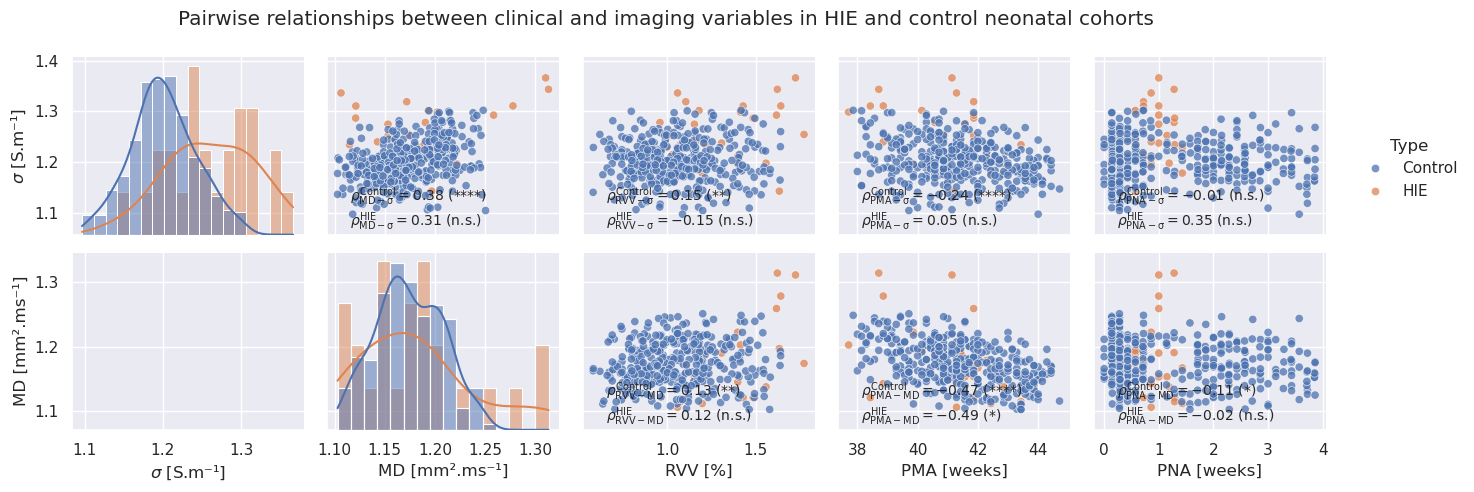

In [4]:
# Set file path
plot_dir = os.path.join(results_dir, "plots", "experiments")
plot_path = os.path.join(plot_dir, "experiment5A.png")

# Load dataframe
df = pd.read_csv(df_path)

#
type_col = "Type"
type_labels = ["Control", "HIE"]
type_idx = []
off = 0
for type_label in type_labels:
    n = len(df[df[type_col] == type_label].index)
    type_idx += [np.arange(off,n+off)]
    off += n

#
df = df.rename(columns={
    "brain_SIG": r"$\sigma$ [S.m⁻¹]",
    "brain_MD": "MD [mm².ms⁻¹]",
    "RVV": "RVV [%]",
    "PNA": "PNA [weeks]",
    "PMA": "PMA [weeks]",
})

# Select x and y variables
x_vars = [
    r"$\sigma$ [S.m⁻¹]",
    "MD [mm².ms⁻¹]",
    "RVV [%]",
    "PMA [weeks]",
    "PNA [weeks]",
]
y_vars = [
    r"$\sigma$ [S.m⁻¹]",
    "MD [mm².ms⁻¹]",
]

# Initialize plot
g = sns.PairGrid(df, hue=type_col, hue_order=type_labels, x_vars=x_vars, y_vars=y_vars)
g.fig.suptitle("Pairwise relationships between clinical and imaging variables in HIE and control neonatal cohorts")

# Plot data
g.map_diag(sns.histplot, kde=True, stat="proportion", common_norm=False)
g.map_upper(sns.scatterplot, alpha=0.75)
g.map_upper(annotate_cat_pairplot, cats=type_labels, cats_idx=type_idx, disp_ci=disp_ci)

# Legend
g.add_legend()
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 0.75))

# Adjust layout
g.fig.tight_layout()

# Save plot
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

It is clear that brain conductivity is higher in HIE babies. The non-significant correlation coefficients may be due to the low number of HIE subjects ($n = 25$).

## 3. Effect of HIE on neonatal brain conductivity

### 3.a. Difference in neonatal variables between HIE and control population
We used Welch $t$-test to compare the distributions HIE and control nenonatal variables. Effect sizes were reported as Cohen's $d$ coefficients.

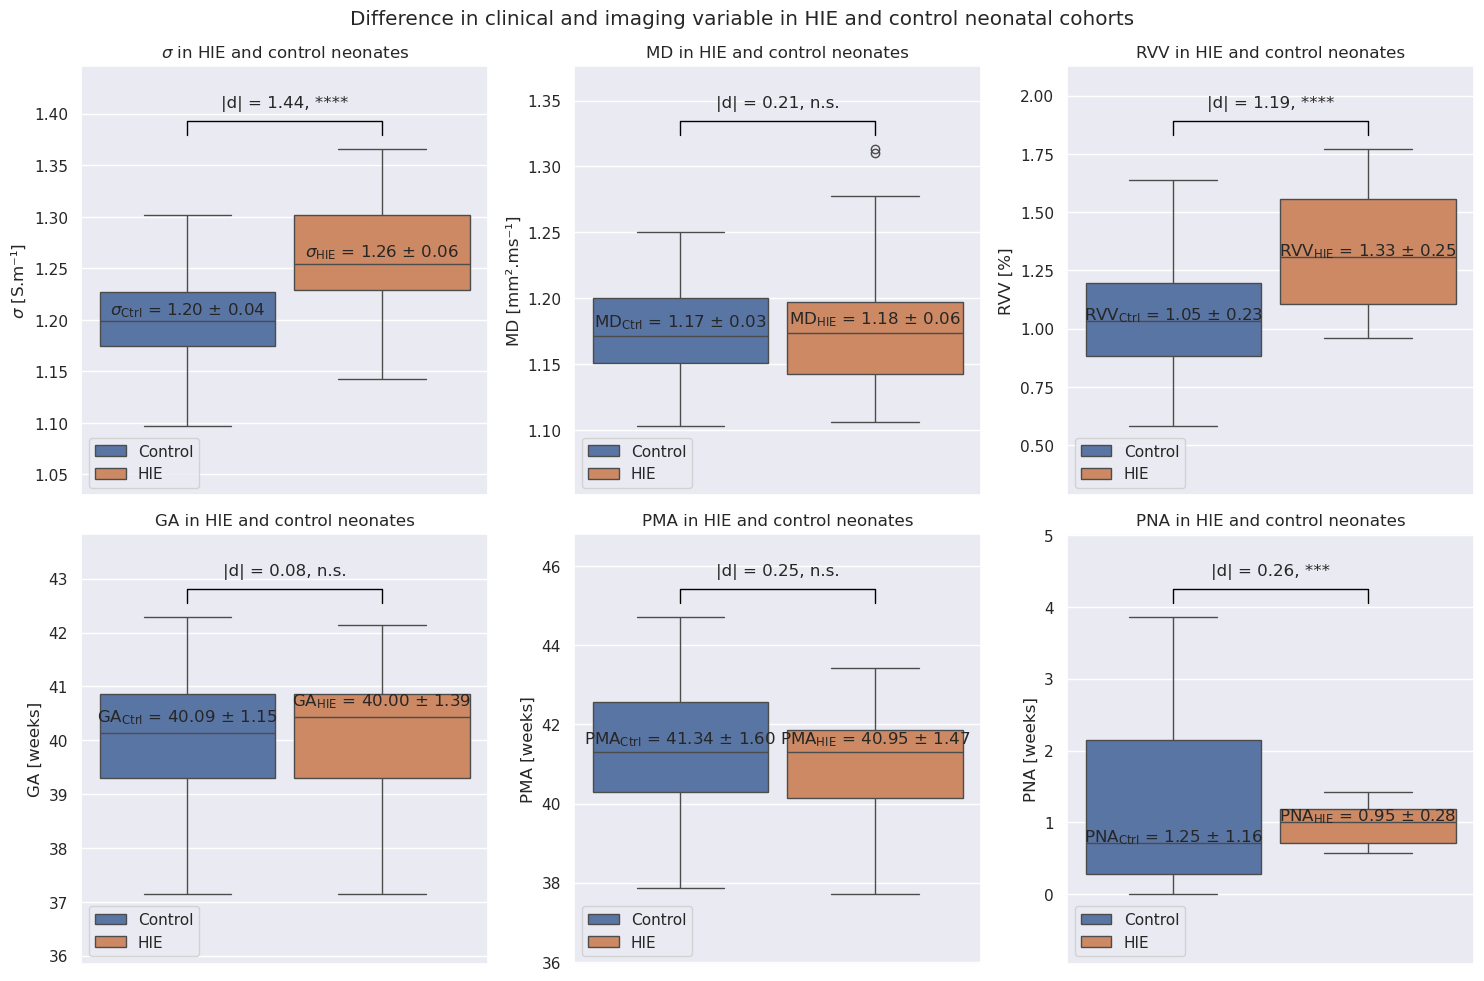

In [5]:
# Set file path
plot_path = os.path.join(plot_dir, "experiment5B.png")

# Load dataframe
df = pd.read_csv(df_path)

#
metrics = ["brain_SIG", "brain_MD", "RVV", "GA", "PMA", "PNA"]
type_col = "Type"
type_labels = ["Control", "HIE"]

#
comparisons = [('Control', 'HIE')]
labels = [r"$\sigma$ [S.m⁻¹]", "MD [mm².ms⁻¹]", "RVV [%]", "GA [weeks]", "PMA [weeks]", "PNA [weeks]"]
symbols = [r"$\sigma$", "MD", "RVV", "GA", "PMA", "PNA"]
bases = [r"\sigma", "\mathregular{MD}", "\mathregular{RVV}", "\mathregular{GA}", "\mathregular{PMA}", "\mathregular{PNA}"]

#
ylims = [calculate_plot_lim(df[metric], coeff_min=0.25, coeff_max=0.3) for metric in metrics]

#
n, m = 2, 3
fig, axes = plt.subplots(n, m, figsize=(15,10))
fig.suptitle(r"Difference in clinical and imaging variable in HIE and control neonatal cohorts")

#
for i, metric in enumerate(metrics):
    # Subplot index
    l, k = i//m, i%m
    #
    sns.boxplot(data=df, ax=axes[l,k], hue=type_col, hue_order=type_labels, y=metric, gap=.1)
    axes[l,k].set_xlabel(None)
    axes[l,k].set_ylabel(labels[i])
    axes[l,k].set_title(f"{symbols[i]} in HIE and control neonates")
    axes[l,k].set_ylim(ylims[i])
    axes[l,k].legend(loc="lower left")
    
# Statistical annotations
for i, metric in enumerate(metrics):
    # Subplot index
    l, k = i//m, i%m
    for j, (g1, g2) in enumerate(comparisons):
        # Welch t-test
        y1 = df[df[type_col] == g1][metric]
        y2 = df[df[type_col] == g2][metric]
        stat, p = ttest_ind(y1, y2, equal_var=False)
        stars = convert_pvalue_to_asterisks(p)

        # 
        eff = np.abs(pg.compute_effsize(y1, y2, paired=False, eftype='cohen'))

        # Bar annotation
        x1 = -0.2
        x2 = 0.2
        y_range = df[metric].max() - df[metric].min()
        y_max = df[metric].max() + (j+1) * 0.05 * y_range
        offset = 0.05 * y_range
        axes[l,k].plot([x1, x1, x2, x2], [y_max, y_max + offset, y_max + offset, y_max], color='black', lw=1)
        axes[l,k].text(j, y_max + offset + 0.05*y_range, f"|d| = {eff:.2f}, {stars}", ha='center')

# Annotation of means ± std
for i, metric in enumerate(metrics):
    # Subplot index
    l, k = i//m, i%m
    for j, cat in enumerate(type_labels):
        # Extract statistics
        group = df[df[type_col] == cat][metric]
        y_mean = group.mean()
        y_std = group.std()
        y_med = group.median()

        # Annotate
        base = bases[i]
        if cat == "Control":
            cat = "Ctrl"
        label = f"${base}_{{\mathregular{{{cat}}}}}$"
        xc = -0.2 if j == 0 else 0.2
        offset = 0.005 * df[metric].max()
        axes[l,k].text(xc, y_med+offset, f"{label} = {y_mean:.2f} ± {y_std:.2f}", ha='center')

# Adjust layout
fig.tight_layout()

# Save plot
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

The largest effect size was reported for conductivity, followed by RVV. There were no significant differences in MD. The population was selected such that the distributions of GA and PMA matched. HIE subjects were selected within a restricted PNA window to control for injury progression.

### 3.b. Effect of HIE on brain conductivity and MD controlling for PMA
We assessed the difference in brain conductivity and MD between control and HIE neonates controlling for PMA through ANCOVA.

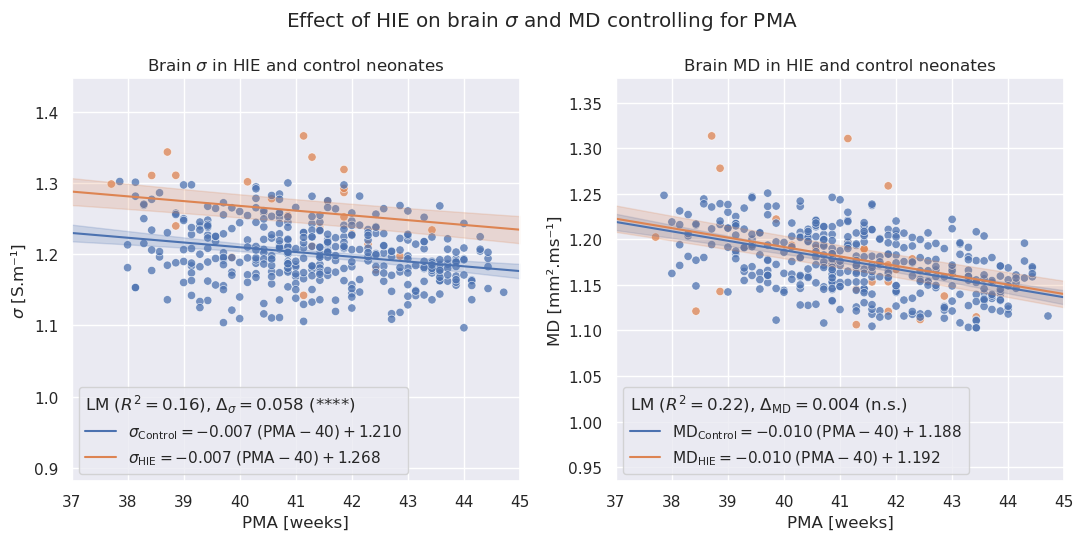

In [6]:
# Set file path
plot_path = os.path.join(plot_dir, "experiment5C.png")
summary_dir = os.path.join(results_dir, "statsmodels")
summary_path = os.path.join(summary_dir, "experiment5C.txt")

# Load dataframe
df = pd.read_csv(df_path)

# Center data
pma_col = "PMA"
pmac_col = "PMA_c"
pma_center = 40
df[pmac_col] = df[pma_col] - pma_center

#
metrics = ["brain_SIG", "brain_MD"]
type_col = "Type"
type_labels = ['Control', 'HIE']

#
labels = [r"$\sigma$ [S.m⁻¹]", "MD [mm².ms⁻¹]"]
symbols = [r"$\sigma$", "MD"]
symbols_latex = ["\sigma", "\mathregular{MD}"]

#
palette = sns.color_palette()

#
xlim = [37, 45]
ylims = [calculate_plot_lim(df[metric], coeff_min=0.8, coeff_max=0.3) for metric in metrics]

#
fig, axes = plt.subplots(1, 2, figsize=(11,5.5))
fig.suptitle(r"Effect of HIE on brain $\sigma$ and MD controlling for PMA")

#
for i, metric in enumerate(metrics):
    #
    formula = f"{metric} ~ {pmac_col} + C({type_col}) - 1"
    lm = smf.ols(formula, df).fit()
    formula = f"{metric} ~ {pmac_col} + C({type_col})"
    lm_inter = smf.ols(formula, df).fit()
    formula = f"{metric} ~ {pmac_col} + C({type_col})*{pmac_col} + C({type_col})"
    lm_inter_pma = smf.ols(formula, df).fit()

    #
    sns.scatterplot(data=df, ax=axes[i], x=pma_col, y=metric, hue=type_col, hue_order=type_labels, alpha=0.75, legend=False)
    axes[i].set_xlabel("PMA [weeks]")
    axes[i].set_ylabel(labels[i])
    axes[i].set_title(f"Brain {symbols[i]} in HIE and control neonates")
    axes[i].set_xlim(xlim)
    axes[i].set_ylim(ylims[i])
    
    for j, cat in enumerate(type_labels):
        n = 100
        X = np.linspace(xlim[0], xlim[1], num=n)
        pred = lm.get_prediction({pmac_col: X-pma_center, type_col: n*[cat]})
        pred_summary = pred.summary_frame(alpha=0.05)  # 95% confidence intervals
    
        slope = lm.params[pmac_col]
        intercept = lm.params[f"C({type_col})[{cat}]"]
    
        slope_txt = f"{slope:.3f}"
        coeff_txt = rf"\; (\mathregular{{PMA}} - {pma_center})"
        intercept_txt = f"+ {intercept:.3f}" if intercept >= 0 else f"- {abs(intercept):.3f}"
        var_symbol = f"{symbols_latex[i]}_{{\mathregular{{{cat}}}}}"
        label = f"${var_symbol} = {slope_txt}{coeff_txt} {intercept_txt}$"
    
        axes[i].plot(X, intercept + slope * (X-pma_center), color=palette[j], label=label)
        axes[i].fill_between(X, pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'], color=palette[j], alpha=0.2) 

    #
    r2 = lm.rsquared
    delta = lm_inter.params[f"C({type_col})[T.{type_labels[1]}]"]
    pval = lm_inter.pvalues[f"C({type_col})[T.{type_labels[1]}]"]
    stars = convert_pvalue_to_asterisks(pval)
    leg = axes[i].legend(loc="lower left", title=rf"LM ($R^2 = {r2:.2f}$), $\Delta_{symbols_latex[i]} = {delta:.3f}$ ({stars})")
    leg._legend_box.align = "left"

    # Write summary
    write_mode = "a" if i else "w"
    with open(summary_path, write_mode) as fh:
        fh.write(lm.summary(slim=True).as_text())
        fh.write("\n\n")
        fh.write(lm_inter.summary(slim=True).as_text())
        fh.write("\n\n")
        fh.write(lm_inter_pma.summary(slim=True).as_text())
        fh.write("\n\n")

# Adjust layout
fig.tight_layout()

# Save plot
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

HIE status was associated with a significant increase in whole-brain conductivity (group mean difference, $\Delta_{\sigma} = 0.058$ $\textrm{S.m}^{-1}$, $95\%\textrm{CI}$ $[0.041, 0.075]$, $\textit{P} < 0.0001$). In contrast, no significant difference in whole-brain MD was detected (group mean difference, $\Delta_{\textrm{MD}} = 0.004$ $\textrm{mm}^{2}\textrm{ms}^{-1}$, $95\%\textrm{CI}$ $[-0.09, 0.016]$, $\textit{P} = 0.584$). 

### 3.c. Effect of HIE on conductivity and MD controlling for PMA within dGM and WM tissues
Similare univariate ANCOVA analysis were performed at tissue level.

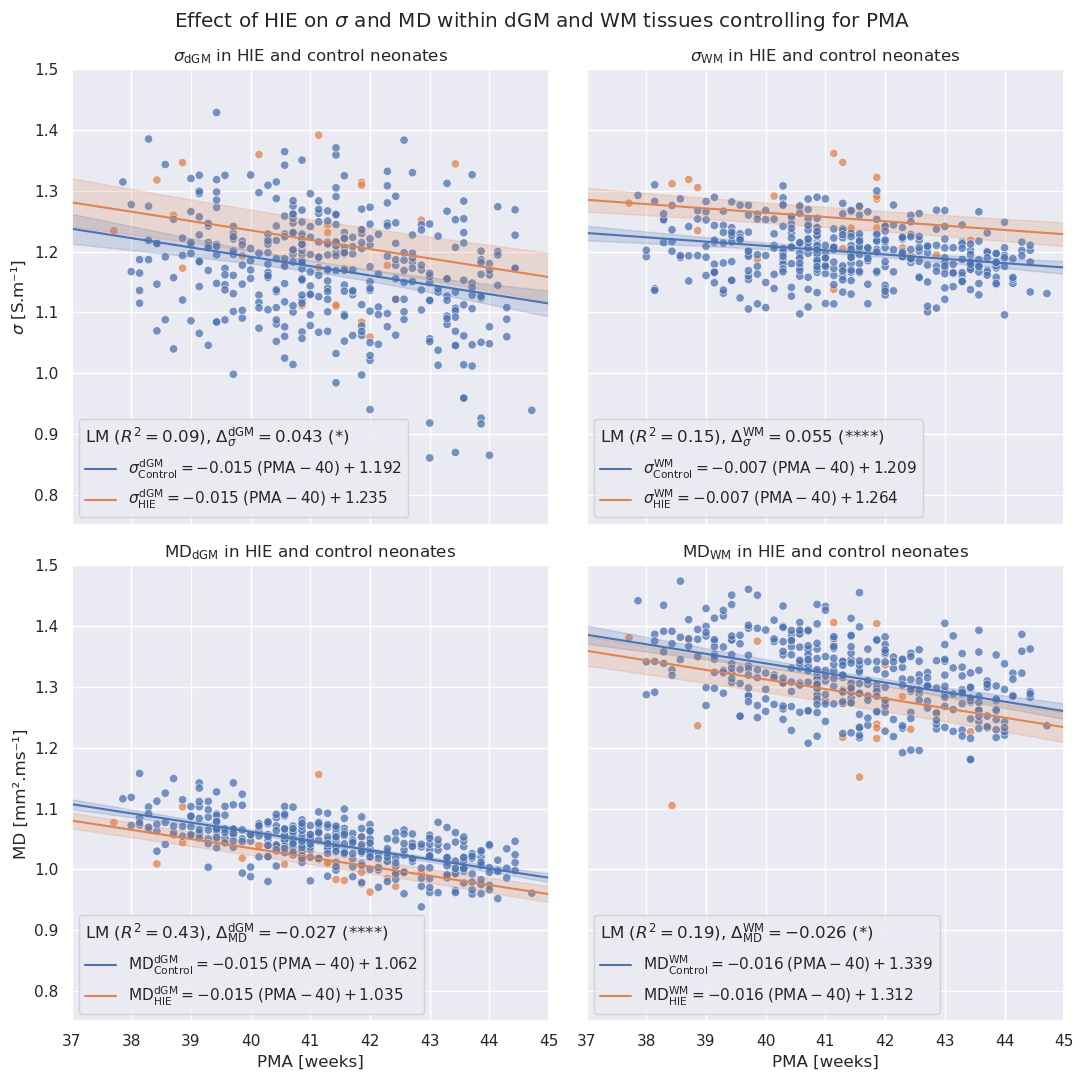

In [7]:
# Set file path
plot_path = os.path.join(plot_dir, "experiment5D.png")
summary_path = os.path.join(summary_dir, "experiment5D.txt")

# Load dataframe
df = pd.read_csv(df_path)

# Center data
pma_col = "PMA"
pmac_col = "PMA_c"
pma_center = 40
df[pmac_col] = df[pma_col] - pma_center

#
metrics = ["SIG", "MD"]
type_col = "Type"
type_labels = ['Control', 'HIE']
tissue_labels = ["dGM", "WM"]

#
labels = [r"$\sigma$ [S.m⁻¹]", "MD [mm².ms⁻¹]"]
symbols = [r"$\sigma$", "MD"]
symbols_latex = ["\sigma", "\mathregular{MD}"]

#
palette = sns.color_palette()

#
xlim = [37, 45]
ylim = [0.75, 1.5]

#
fig, axes = plt.subplots(2, 2, figsize=(11,11), sharey="row", sharex="col")
fig.suptitle(r"Effect of HIE on $\sigma$ and MD within dGM and WM tissues controlling for PMA")

#
for i, metric in enumerate(metrics):
    for j, tissue in enumerate(tissue_labels):
        #
        formula = f"{tissue}_{metric} ~ {pmac_col} + C({type_col}) - 1"
        lm = smf.ols(formula, df).fit()
        formula = f"{tissue}_{metric} ~ {pmac_col} + C({type_col})"
        lm_inter = smf.ols(formula, df).fit()
        formula = f"{tissue}_{metric} ~ {pmac_col} + C({type_col})*{pmac_col} + C({type_col})"
        lm_inter_pma = smf.ols(formula, df).fit()

        #
        sns.scatterplot(data=df, ax=axes[i,j], x=pma_col, y=f"{tissue}_{metric}", hue=type_col, hue_order=type_labels, alpha=0.75, legend=False)
        axes[i,j].set_xlabel("PMA [weeks]")
        axes[i,j].set_ylabel(labels[i])
        axes[i,j].set_title(f"${symbols_latex[i]}_{{\mathregular{{{tissue}}}}}$ in HIE and control neonates")
        axes[i,j].set_xlim(xlim)
        axes[i,j].set_ylim(ylim)
        
        for k, cat in enumerate(type_labels):
            n = 100
            X = np.linspace(xlim[0], xlim[1], num=n)
            pred = lm.get_prediction({pmac_col: X-pma_center, type_col: n*[cat]})
            pred_summary = pred.summary_frame(alpha=0.05)  # 95% confidence intervals
        
            slope = lm.params[pmac_col]
            intercept = lm.params[f"C({type_col})[{cat}]"]
        
            slope_txt = f"{slope:.3f}"
            coeff_txt = rf"\; (\mathregular{{PMA}} - {pma_center})"
            intercept_txt = f"+ {intercept:.3f}" if intercept >= 0 else f"- {abs(intercept):.3f}"
            var_symbol = f"{symbols_latex[i]}_{{\mathregular{{{cat}}}}}^{{\mathregular{{{tissue}}}}}"
            label = f"${var_symbol} = {slope_txt}{coeff_txt} {intercept_txt}$"
        
            axes[i,j].plot(X, intercept + slope * (X-pma_center), color=palette[k], label=label)
            axes[i,j].fill_between(X, pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'], color=palette[k], alpha=0.2) 
    
        #
        r2 = lm.rsquared
        delta = lm_inter.params[f"C({type_col})[T.{type_labels[1]}]"]
        pval = lm_inter.pvalues[f"C({type_col})[T.{type_labels[1]}]"]
        stars = convert_pvalue_to_asterisks(pval)
        leg = axes[i,j].legend(loc="lower left", title=rf"LM ($R^2 = {r2:.2f}$), $\Delta_{symbols_latex[i]}^{{\mathregular{{{tissue}}}}} = {delta:.3f}$ ({stars})") 
        leg._legend_box.align = "left"

        # Write summary
        write_mode = "w" if (i == 0 and j == 0) else "a"
        with open(summary_path, write_mode) as fh:
            fh.write(lm.summary(slim=True).as_text())
            fh.write("\n\n")
            fh.write(lm_inter.summary(slim=True).as_text())
            fh.write("\n\n")
            fh.write(lm_inter_pma.summary(slim=True).as_text())
            fh.write("\n\n")

# Adjust layout
fig.tight_layout()

# Save plot
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

Regional analysis showed that MD reductions in HIE were focal, with significant decreases in both dGM and WM after adjusting for PMA (group mean differences; $\Delta_{\textrm{MD}}^{\textrm{dGM}} = -0.027$ $\textrm{mm}^{2}\textrm{ms}^{-1}$, $95\%\textrm{CI}$ $[-0.038, -0.016]$, $\textit{P} < 0.0001$; $\Delta_{\textrm{MD}}^{\textrm{WM}} = -0.026$ $\textrm{mm}^{2}\textrm{ms}^{-1}$, $95\%\textrm{CI}$ $[-0.048, -0.005]$, $\textit{P} < 0.05$). Notably, MD and conductivity changed in opposite directions, with conductivity increasing in dGM and WM despite MD reductions (group mean differences; $\Delta_{\sigma}^{\textrm{dGM}} = 0.043$ $\textrm{S.m}^{-1}$, $95\%\textrm{CI}$ $[0.008, 0.078]$, $\textit{P} < 0.05$; $\Delta_{\sigma}^{\textrm{WM}} = 0.055$ $\textrm{S.m}^{-1}$, $95\%\textrm{CI}$ $[0.038, 0.072]$, $\textit{P} < 0.0001$).

### 3.d. Effect of HIE on conductivity within dGM and WM
A multivariate LME model was fitted to the neonatal $\sigma_{\textrm{dGM}}$ and $\sigma_{\textrm{WM}}$ conductivity values from the control and brain-injured cohorts with MD, RVV, PTB and PMA as explanatory variables. The model incorporated mixed-effects to account for the interdependence of $\sigma_{\textrm{dGM}}$ and $\sigma_{\textrm{WM}}$ measurements performed on the same subjects and included interaction terms between tissue type and all predictor variables. Additionally, interaction terms between cohort type, intercept and MD variables were incorporated to evaluate the impact of HIE brain injury. Proportional effect coefficients were also computed and reported at tissue level.

In [8]:
def center_df():
    # Center data
    for var_col in var_cols:
        df[var_col] -= df[var_col].mean()
    for tissue in tissue_labels:
        for var_tissue_col in var_tissue_cols:
            if var_tissue_col != y_col:
                df[f"{tissue}_{var_tissue_col}"] -= df[f"{tissue}_{var_tissue_col}"].mean()
    return df

def normalize_df():
    # Normalize data
    for var_col in var_cols:
        df[var_col] /= df[var_col].std()
    for tissue in tissue_labels:
        for var_tissue_col in var_tissue_cols:
            if var_tissue_col != y_col:
                df[f"{tissue}_{var_tissue_col}"] /= df[f"{tissue}_{var_tissue_col}"].std()
            else:
                df[f"{tissue}_{y_col}"] = (df[f"{tissue}_{y_col}"] - df[f"{tissue}_{y_col}"].mean()) / df[f"{tissue}_{y_col}"].std()
    return df

def build_vert_df():
    # Build vertical datafrane
    vert_df = []
    for tissue in tissue_labels:
        temp_df = {}
        for var_col in var_cols:
            temp_df[var_col] = df[var_col].values
        for var_tissue_col in var_tissue_cols:
            temp_df[var_tissue_col] = df[f"{tissue}_{var_tissue_col}"].values
        temp_df[tissue_col] = tissue
        temp_df[type_col] = df[type_col]
        temp_df[groups_col] = df[groups_col]
        vert_df.append(pd.DataFrame(temp_df))
    
    # Concatenate
    vert_df = pd.concat(vert_df, ignore_index=True)
    return vert_df

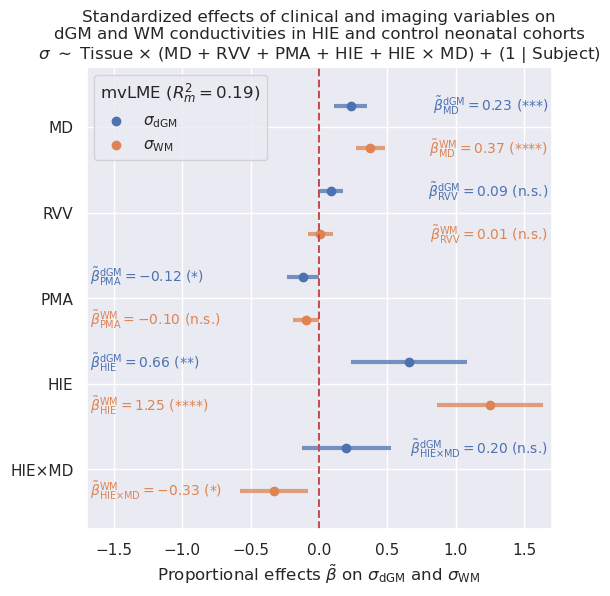

In [9]:
# Set file path
plot_path = os.path.join(plot_dir, "experiment5E.png")
summary_path = os.path.join(summary_dir, "experiment5E.txt")

# Load dataframe
df = pd.read_csv(df_path)

# Data header
x_cols = ["PMA", "RVV", "MD"]
y_col = "SIG"
var_cols = ["PMA", "RVV"]
var_tissue_cols = ["SIG", "MD"]
tissue_col = "Tissue"
tissue_labels = ["dGM", "WM"]
type_col = "Type"
type_labels = ["Control", "HIE"]
groups_col = "subject_id"

# Center data
df = center_df()

# Build vertical datafrane
vert_df = build_vert_df()

# Fit mixed effects model
x_str = []
for x_col in x_cols:
    if x_col not in var_tissue_cols:
        x_str += [f"{x_col} + C({tissue_col})*{x_col} - {x_col}"]
    else:
        x_str += [f"{x_col} + C({tissue_col})*{x_col} +  C({tissue_col})*C({type_col})*{x_col} - C({type_col})*{x_col} - {x_col}"]
formula = f"{y_col} ~ {' + '.join(x_str)} + C({tissue_col}) + C({type_col}) + C({tissue_col})*C({type_col}) - 1 - C({type_col})"
lme = smf.mixedlm(formula=formula, data=vert_df, groups=vert_df[groups_col]).fit(reml=False)

# Coefficient of determination
marginal_r2, conditional_r2 = lme_coefficient_determination(lme, vert_df)

# Normalize data
df = normalize_df()

# Build vertical datafrane
vert_df = build_vert_df()

# Fit mixed effects model (proportional effects)
lme_prop = smf.mixedlm(formula=formula, data=vert_df, groups=vert_df[groups_col]).fit(reml=False)

# Coefficients of determination
marginal_r2_prop, conditional_r2_prop = lme_coefficient_determination(lme_prop, vert_df)

# Labels
yticks = ["HIE×MD", "HIE", "PMA", "RVV", "MD"]
n = len(tissue_labels)
m = len(yticks)
xlim = [-1.7, 1.7]
ylim = [-0.7, 4.7]
palette = sns.color_palette()

# Initialize plot
fig, ax = plt.subplots(figsize=(6,6))
ax.set_title("Standardized effects of clinical and imaging variables on\n"
             "dGM and WM conductivities in HIE and control neonatal cohorts\n"
             r"$\sigma$ $\sim$ Tissue $\times$ (MD + RVV + PMA + HIE + HIE $\times$ MD) + (1 | Subject)")

# Iter over tissue
for i, tissue in enumerate(tissue_labels):
    y_off = (1-2*i)*0.25
    params = []
    pvals = []
    cis = []
    for j, ytick in enumerate(yticks):
        if ytick == "HIE":
            params += [lme_prop.params[f"C({tissue_col})[{tissue}]:C({type_col})[T.{ytick}]"]]
            pvals += [lme_prop.pvalues[f"C({tissue_col})[{tissue}]:C({type_col})[T.{ytick}]"]]
            cis += [lme_prop.conf_int().loc[f"C({tissue_col})[{tissue}]:C({type_col})[T.{ytick}]"]]
        elif ytick == "HIE×MD":
            t1 = ytick.split("×")[0]
            t2 = ytick.split("×")[1]
            params += [lme_prop.params[f"C({tissue_col})[{tissue}]:C({type_col})[T.{t1}]:{t2}"]]
            pvals += [lme_prop.pvalues[f"C({tissue_col})[{tissue}]:C({type_col})[T.{t1}]:{t2}"]]
            cis += [lme_prop.conf_int().loc[f"C({tissue_col})[{tissue}]:C({type_col})[T.{t1}]:{t2}"]]
        else:
            params += [lme_prop.params[f"C({tissue_col})[{tissue}]:{ytick}"]]
            pvals += [lme_prop.pvalues[f"C({tissue_col})[{tissue}]:{ytick}"]]
            cis += [lme_prop.conf_int().loc[f"C({tissue_col})[{tissue}]:{ytick}"]]
    # Plot effects
    ax.scatter(params, np.arange(m)+y_off, zorder=2, color=palette[i], label=rf"$\sigma_{{\mathregular{{{tissue}}}}}$")

    # Iter over predictors
    for idx, ci in enumerate(cis):
        # Add the confidence interval error bars
        ax.hlines(idx+y_off, ci[0], ci[1], color=palette[i], zorder=1, linewidth=3, alpha=0.75)

        # Label
        ha = "right" if params[idx]>0 else "left"
        x = 1.675 if params[idx]>0 else -1.675
        if yticks[idx] == "HIE":
            ha = "left"
            x = -1.675
        y = idx 
        stars = convert_pvalue_to_asterisks(pvals[idx])
        a = rf"\tilde{{\beta}}_{{\mathregular{{{yticks[idx]}}}}}^{{\mathregular{{{tissue}}}}}"
        ax.text(x, y+y_off, f"${a} = {params[idx]:.2f}$ ({stars})", ha=ha, va="center", size="small", c=palette[i])

# Add dashed line at 0.0
plt.axline((0,0), (0,1), color="r", linestyle="--") 

# Axis labels and linits
ax.set_yticks(range(m), yticks)
ax.set_xlabel(r"Proportional effects $\tilde{\beta}$ on $\sigma_{\mathregular{dGM}}$ and $\sigma_{\mathregular{WM}}$")
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Legend
leg = ax.legend(loc="upper left", title=f"mvLME ($R^2_m = {marginal_r2_prop:.2f}$)")
leg._legend_box.align = "left"

# Initialize output directories
for path in [summary_path, plot_path]:
    output_dir = os.path.dirname(path)
    os.makedirs(output_dir, exist_ok=True)
    
# Save plot
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

# Write summary
with open(summary_path, "w") as fh:
    fh.write(lme.summary().as_text())
    fh.write(f"\nMarginal R² = {marginal_r2:.2f}, Conditional R² = {conditional_r2:.2f}\n\n")
    fh.write(lme_prop.summary().as_text())
    fh.write(f"\nMarginal R² = {marginal_r2_prop:.2f}, Conditional R² = {conditional_r2_prop:.2f}\n\n")

Multivariate mixed-effects models controlling for PMA, MD, and RVV confirmed an increase in conductivity in HIE neonates within both tissues (group mean differences; $\Delta_{\sigma}^{\textrm{dGM}} = 0.061$ $\textrm{S.m}^{-1}$, $95\%\textrm{CI}$ $[0.030, 0.092]$, $\textit{P} < 0.0001$; $\Delta_{\sigma}^{\textrm{WM}} = 0.057$ $\textrm{S.m}^{-1}$, $95\%\textrm{CI}$ $[0.029, 0.092]$, $\textit{P} < 0.0001$), in agreement with the univariate findings. Analysis of standardized proportional effects showed that HIE status exerted the largest influence on conductivity among all predictors (proportional effects; $\beta_{\textrm{HIE}}^{\textrm{dGM}} = 0.66$, $95\%\textrm{CI}$ $[0.24, 1.08]$, $\textit{P} < 0.01$; $\beta_{\textrm{HIE}}^{\textrm{WM}} = 1.25$, $95\%\textrm{CI}$ $[0.86, 1.64]$, $\textit{P} < 0.0001$). This indicates that brain injury has a substantially greater impact on conductivity than maturational (PMA) or structural (MD and RVV) variables. Furthermore, white matter conductivity being much more affected by HIE than deep grey matter is consistent with known selective vulnerability of WM in hypoxic–ischemic injury.

Effects of PMA, MD, and RVV aligned with prior results, indicating that although MD contributes more substantially to conductivity decrease than PMA and RVV, a residual age-dependent effect persists in dGM tissue, while RVV did not show significant associations with $\sigma_{\textrm{dGM}}$ or $\sigma_{\textrm{WM}}$. Finally, HIE significantly weakens (or reverses) the $\sigma$–MD relationship in WM, and on the contrary strengthens it in dGM (proportional effects; $\beta_{\textrm{HIE}\times\textrm{MD}}^{\textrm{dGM}} = 0.20$, $95\%\textrm{CI}$ $[-0.13, 0.53]$, $\textit{P} = 0.233$; $\beta_{\textrm{HIE}\times\textrm{MD}}^{\textrm{WM}} = -0.33$, $95\%\textrm{CI}$ $[-0.58, -0.08]$, $\textit{P} < 0.05$). Opposite effects suggest tissue-specific vulnerability and underlying biophysical mechanisms for conductivity changes.

## 4. Mediation effects of MD and RVV on HIE-conductivity association whithin dGM and WM tissues. 
To investigate potential pathways linking HIE to altered brain electrical conductivity, a parallel mediation analysis was conducted in control neonates (n = 379) and infants with brain injury secondary to HIE (n = 25). MD and RVV were specified a priori as candidate mediators based on their established sensitivity to HIE  tissue injury and structural brain alterations. PMA was included as a controlling covariate.

Total, direct, and indirect effects of HIE on conductivity were estimated within a regression-based mediation framework for dGM and WM tissue separately. Indirect effects were quantified as the product of the HIE-mediator and mediator-conductivity coefficients. Statistical significance was computed in a similar fashion to previous mediation analysis. Variables were $z$-scored normalize prior to analysis.

**Caution**: Because the data are cross-sectional, mediation should not be interpreted as definitive causal effects but consistent with injury pathways.

In [10]:
# Load dataframe
df = pd.read_csv(df_path)

# To float
y_col = "Type"
y_labels = ["Control", "HIE"]
for i, y_label in enumerate(y_labels):
    df.loc[df[y_col] == y_label, y_col] = i
df[y_col] = df[y_col].astype(float)

# Set headers
x_col = "Type"
y_dGM_col = "dGM_SIG"
y_WM_col = "WM_SIG"
mediator_dGM_cols = ["dGM_MD", "RVV"]
mediator_WM_cols = ["WM_MD", "RVV"]
covar_cols = ["PMA"]

# Center and normalize
for col in [y_dGM_col, y_WM_col] + mediator_dGM_cols + mediator_WM_cols + covar_cols:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

In [11]:
print("Mediation analysis - dGM")
mediation_analysis(data=df, x=x_col, m=mediator_dGM_cols, y=y_dGM_col, covar=covar_cols, alpha=0.05, seed=42)

Mediation analysis - dGM


,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,dGM_MD ~ X,-0.725496,0.155898,4.438016e-06,-1.031976,-0.419016,Yes
1,RVV ~ X,1.142393,0.199338,1.965096e-08,0.750515,1.534270,Yes
2,Y ~ dGM_MD,0.212031,0.060897,5.529820e-04,0.092313,0.331749,Yes
3,Y ~ RVV,0.129724,0.047008,6.053312e-03,0.037310,0.222138,Yes
4,Total,0.481617,0.197714,1.528851e-02,0.092931,0.870303,Yes
5,Direct,0.554099,0.206244,7.519683e-03,0.148638,0.959561,Yes
6,Indirect dGM_MD,-0.180455,0.062281,4.000000e-03,-0.302636,-0.069837,Yes
7,Indirect RVV,0.107973,0.066867,8.800000e-02,-0.004100,0.262224,No


In [12]:
print("Mediation analysis - WM")
mediation_analysis(data=df, x=x_col, m=mediator_WM_cols, y=y_WM_col, covar=covar_cols, alpha=0.05, seed=42)

Mediation analysis - WM


,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,WM_MD ~ X,-0.452008,0.186682,1.590910e-02,-0.819005,-0.085011,Yes
1,RVV ~ X,1.142393,0.199338,1.965096e-08,0.750515,1.534270,Yes
2,Y ~ WM_MD,0.263732,0.051279,4.241610e-07,0.162921,0.364542,Yes
3,Y ~ RVV,0.085942,0.046506,6.534696e-02,-0.005486,0.177369,No
4,Total,1.199483,0.190787,8.459647e-10,0.824415,1.574551,Yes
5,Direct,1.342951,0.191306,9.604282e-12,0.966856,1.719045,Yes
6,Indirect WM_MD,-0.139260,0.092739,1.320000e-01,-0.310631,0.056344,No
7,Indirect RVV,-0.004208,0.054090,9.200000e-01,-0.109685,0.090506,No


Tissue-level mediation analysis further demonstrated that the association between HIE and conductivity was partially mediated by MD in dGM but not in WM (MD indirect effects, dGM: $-0.18$, $95\%\textrm{CI}$ $[-0.30, -0.07]$, $\textit{P} < 0.001$; WM: $-0.14$, $95\%\textrm{CI}$ $[-0.31, 0.06]$, $\textit{P} = 0.13$). RVV did not significantly mediate this relationship in either tissue.
Importantly, the direct effect of HIE remained the dominant contributor to elevated conductivity, particularly in white matte (HIE direct effects, dGM: $0.55$, $95\%\textrm{CI}$ $[0.15, 0.95]$, $\textit{P} < 0.01$; WM: $1.34$, $95\%\textrm{CI}$ $[0.97, 1.72]$, $\textit{P} < 0.0001$), supporting the presence of injury-related mechanisms not fully captured by diffusion or volumetric markers.

## 5. HIE classification using quantitative imaging measurements

### 5.a. HIE classification using brain conductivity and MD
A multivariate logistic binary classifier model was fitted on HIE/control status using quantitative imaging measurements (i.e., $\sigma$, MD and RVV) as predictors. PMA was included as a control variables to account for potential cohort-specific differences in scan timing. Variables were $z$-score normalized and standardized odds ratios (OR) were computed from the estimated model coefficients. Odds ratios were reported along their confidence intervals. Model goodness of fit was measured using McFadden pseudo-$R^2$ ($R^2_{\textrm{McF}}$).

In [13]:
def center_df():
    # Center data
    for x_col in x_cols:
        df[x_col] -= df[x_col].mean()
    return df

def normalize_df():
    # Normalize data
    for x_col in x_cols:
        df[x_col] /= df[x_col].std()
    return df

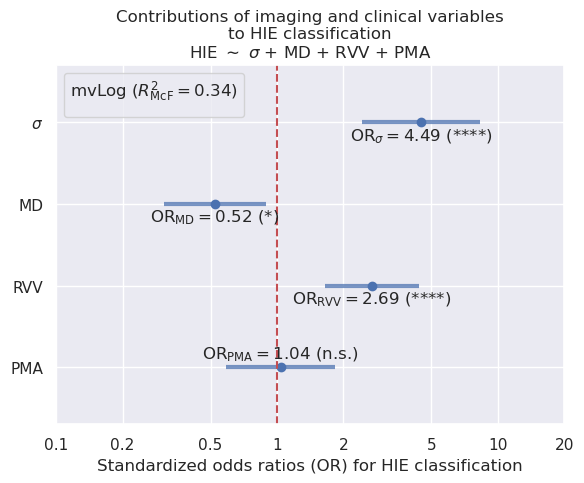

In [14]:
# Set file path
plot_path = os.path.join(plot_dir, "experiment5F.png")
summary_path = os.path.join(summary_dir, "experiment5F.txt")

# Load dataframe
df = pd.read_csv(df_path)

# Data header
x_cols = ["brain_SIG", "brain_MD", "RVV", "PMA"]
y_col = "Type"
y_labels = ["Control", "HIE"]

# Center data
df = center_df()

# Normalize data
df = normalize_df()

# To float for logistic model
for i, y_label in enumerate(y_labels):
    df.loc[df[y_col] == y_label, y_col] = i
df[y_col] = df[y_col].astype(float)

# Fit logistic model
formula = f"{y_col} ~ {' + '.join(x_cols)}"
lgm = smf.logit(formula, df).fit(disp=False)

# Labels and limits
yticks = ["PMA", "RVV", "MD", "SIG"]
labels = ["PMA", "RVV", "MD", r"$\sigma$"]
symbols = ["\mathregular{PMA}", "\mathregular{RVV}", "\mathregular{MD}", "\sigma"]
xlim = [0.1, 20]
ylim = [-0.7, 3.7]

# Initialize plot
fig, ax = plt.subplots(figsize=(6,5))
ax.set_title("Contributions of imaging and clinical variables\n"
             "to HIE classification\n"
             r"HIE $\sim$ $\sigma$ + MD + RVV + PMA")

# Extract data
params = []
pvals = []
cis = []
for j, ytick in enumerate(yticks):
    if ytick == "MD" or ytick == "SIG":
        ytick = f"brain_{ytick}"
    params += [np.exp(lgm.params[ytick])]
    pvals += [lgm.pvalues[ytick]]
    cis += [np.exp(lgm.conf_int().loc[ytick])]

# Plot OR effects
ax.scatter(params, range(len(params)), color="b", zorder=2)

# Iter over predictor
for idx, ytick in enumerate(yticks):
    # Add the confidence interval error bars
    ci = cis[idx]
    ax.hlines(idx, ci[0], ci[1], color="b", zorder=1, linewidth=3, alpha=0.75)

    # Label
    va = "top" if idx > 0 else "bottom"
    y = idx - 0.05 if idx > 0 else idx + 0.05
    stars = convert_pvalue_to_asterisks(pvals[idx])
    a = rf"\mathregular{{OR}}_{{{symbols[idx]}}}"
    ax.text(params[idx], y, f"${a} = {params[idx]:.2f}$ ({stars})", va=va, ha="center")

# Add dashed line at 0.0
plt.axline((1,0), (1,1), color="r", linestyle="--")

# Axis labels and linits
ax.set_yticks(range(len(params)), labels)
ax.set_xlabel(r"Standardized odds ratios (OR) for HIE classification")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xscale("log")
xticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20]
ax.set_xticks(ticks=xticks, labels=xticks, minor=False)

# Legend
rsquared = lgm.prsquared
leg = ax.legend(loc="upper left", title=f"mvLog ($R^2_{{\mathregular{{McF}}}} = {rsquared:.2f}$)")
leg._legend_box.align = "left"

# Adjust layout
fig.tight_layout()

# Initialize output directories
for path in [summary_path, plot_path]:
    output_dir = os.path.dirname(path)
    os.makedirs(output_dir, exist_ok=True)
    
# Save plot
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

# Write summary
with open(summary_path, "w") as fh:
    fh.write(lgm.summary().as_text())

Brain conductivity was a strong independent predictor of HIE status (odds ratio, $\textrm{OR}_{\sigma} = 4.49$, $95\%\textrm{CI}$ $[2.44, 8.29]$, $\textit{P} < 0.0001$), more dominant than MD (odds ratio, $\textrm{OR}_{\textrm{MD}} = 0.52$, $95\%\textrm{CI}$ $[0.31, 0.89]$, $\textit{P} < 0.05$) and remaining significant after controlling for PMA and RVV. Lower MD and higher RVV were also independently associated with increased odds of HIE, whereas PMA showed no independent effect. Conductivity provided the largest independent contribution to HIE classification, supporting its role as a complementary imaging marker beyond diffusion MRI.

### 5.b. HIE classification using dGM and WM tissues conductivity and MD
A multivariate logistic binary classifier model was fitted on HIE/control status using tissue-level quantitative imaging measurements (i.e., $\sigma_{\textrm{dGM}}$, $\sigma_{\textrm{WM}}$, $\textrm{MD}_{\textrm{dGM}}$, $\textrm{MD}_{\textrm{WM}}$) and subject-level variables (i.e., RVV and PMA) as predictors. PMA was included as a control variables to account for potential cohort-specific differences in scan timing. Variables were $z$-score normalized and standardized odds ratios (OR) were computed from the estimated model coefficients. Odds ratios were reported along their confidence intervals. Model goodness of fit was measured using McFadden pseudo-$R^2$ ($R^2_{\textrm{McF}}$).

The logistic model did not incorporated mixed-effects to account for the interdependence of tissue-level measurements performed on the same subjects as mixed-effect logistic regression as it is not currently implemented in statsmodels.

In [15]:
def center_df():
    # Center data
    for var_col in var_cols:
        df[var_col] -= df[var_col].mean()
    for tissue in tissue_labels:
        for var_tissue_col in var_tissue_cols:
            df[f"{tissue}_{var_tissue_col}"] -= df[f"{tissue}_{var_tissue_col}"].mean()
    return df

def normalize_df():
    # Normalize data
    for var_col in var_cols:
        df[var_col] /= df[var_col].std()
    for tissue in tissue_labels:
        for var_tissue_col in var_tissue_cols:
            df[f"{tissue}_{var_tissue_col}"] /= df[f"{tissue}_{var_tissue_col}"].std()
    return df

def build_vert_df():
    # Build vertical datafrane
    vert_df = []
    for tissue in tissue_labels:
        temp_df = {}
        for var_col in var_cols:
            temp_df[var_col] = df[var_col].values
        for var_tissue_col in var_tissue_cols:
            temp_df[var_tissue_col] = df[f"{tissue}_{var_tissue_col}"].values
        temp_df[tissue_col] = tissue
        temp_df[y_col] = df[y_col]
        vert_df.append(pd.DataFrame(temp_df))
    
    # Concatenate
    vert_df = pd.concat(vert_df, ignore_index=True)
    return vert_df

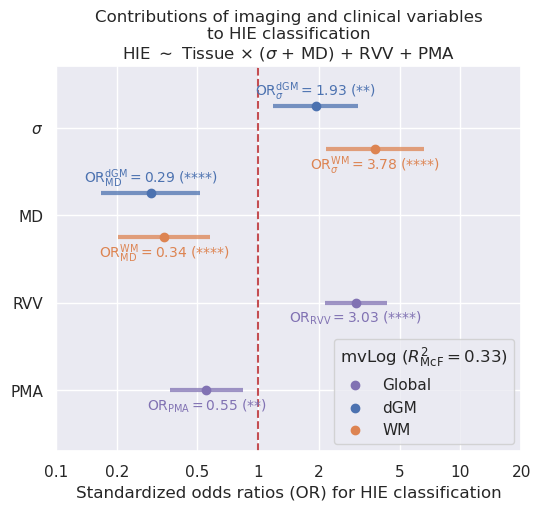

In [16]:
# Set file path
plot_path = os.path.join(plot_dir, "experiment5G.png")
summary_path = os.path.join(summary_dir, "experiment5G.txt")

# Load dataframe
df = pd.read_csv(df_path)

# Data header
x_cols = ["SIG", "MD", "RVV", "PMA"]
y_col = "Type"
y_labels = ["Control", "HIE"]
var_cols = ["PMA", "RVV"]
var_tissue_cols = ["MD", "SIG"]
tissue_col = "Tissue"
tissue_labels = ["dGM", "WM"]
labels = ["PMA", "RVV", "MD", r"$\sigma$"]
symbols = ["\mathregular{PMA}", "\mathregular{RVV}"]
symbols_tissue = ["\mathregular{MD}", "\sigma"]

# To float for logistic model
for i, y_label in enumerate(y_labels):
    df.loc[df[y_col] == y_label, y_col] = i
df[y_col] = df[y_col].astype(float)

# Center data
df = center_df()

# Normalize data
df = normalize_df()

# Build vertical datafrane
vert_df = build_vert_df()

# Fit logistic model
x_str = []
for x_col in x_cols:
    if x_col not in var_tissue_cols:
        x_str += [x_col]
    else:
        x_str += [f"{x_col} + C({tissue_col})*{x_col} - {x_col}"]
formula = f"{y_col} ~ {' + '.join(x_str)} + C({tissue_col}) - 1"
lgm = smf.logit(formula, vert_df).fit(disp=False)

# Labels
yticks = ["PMA", "RVV", "MD", "SIG"]
n = len(tissue_labels)
m = len(var_cols)
k = len(var_tissue_cols)
xlim = [0.1, 20]
ylim = [-0.7, 3.7]
palette = sns.color_palette()

# Initialize plot
fig, ax = plt.subplots(figsize=(6,5))
ax.set_title("Contributions of imaging and clinical variables\n"
             "to HIE classification\n"
             r"HIE $\sim$ Tissue $\times$ ($\sigma$ + MD) + RVV + PMA")
#
params = []
pvals = []
cis = []
for j, var_col in enumerate(var_cols):
    params += [np.exp(lgm.params[var_col])]
    pvals += [lgm.pvalues[var_col]]
    cis += [np.exp(lgm.conf_int().loc[var_col])]

# Plot OR effects
ax.scatter(params, range(m), color=palette[k+2], zorder=2, label="Global")

# Iter over predictor
for idx, ci in enumerate(cis):
    # Add the confidence interval error bars
    ax.hlines(idx, ci[0], ci[1], color=palette[k+2], zorder=1, linewidth=3, alpha=0.75)

    # Label
    va = "top"
    y = idx - 0.075
    stars = convert_pvalue_to_asterisks(pvals[idx])
    a = rf"\mathregular{{OR}}_{{{symbols[idx]}}}"
    ax.text(params[idx], y, f"${a} = {params[idx]:.2f}$ ({stars})", va=va, ha="center", size="small", c=palette[k+2])

# Iter over tissue
for i, tissue in enumerate(tissue_labels):
    
    y_off = (1-2*i)*0.25
    params = []
    pvals = []
    cis = []
    for j, var_tissue_col in enumerate(var_tissue_cols):
        params += [np.exp(lgm.params[f"C({tissue_col})[{tissue}]:{var_tissue_col}"])]
        pvals += [lgm.pvalues[f"C({tissue_col})[{tissue}]:{var_tissue_col}"]]
        cis += [np.exp(lgm.conf_int().loc[f"C({tissue_col})[{tissue}]:{var_tissue_col}"])]
    # Plot effects
    ax.scatter(params, np.arange(m, m+k)+y_off, zorder=2, color=palette[i], label=tissue)

    # Iter over predictors
    for idx, ci in enumerate(cis):
        # Add the confidence interval error bars
        ax.hlines(m+idx+y_off, ci[0], ci[1], color=palette[i], zorder=1, linewidth=3, alpha=0.75)

        # Label
        va = "top" if i > 0 else "bottom"
        y = m+idx+y_off - 0.05 if i > 0 else m+idx+y_off + 0.05
        ha = "center"
        stars = convert_pvalue_to_asterisks(pvals[idx])
        a = rf"\mathregular{{OR}}_{{{symbols_tissue[idx]}}}^{{\mathregular{{{tissue}}}}}"
        ax.text(params[idx], y, f"${a} = {params[idx]:.2f}$ ({stars})", ha=ha, va=va, size="small", c=palette[i])

# Add dashed line at 1.0
plt.axline((1,0), (1,1), color="r", linestyle="--") 

# Axis labels and linits
ax.set_yticks(range(m+k), labels)
ax.set_xlabel(r"Standardized odds ratios (OR) for HIE classification")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xscale("log")
xticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20]
ax.set_xticks(ticks=xticks, labels=xticks, minor=False)

# Legend
rsquared = lgm.prsquared
leg = ax.legend(loc="lower right", title=f"mvLog ($R^2_{{\mathregular{{McF}}}} = {rsquared:.2f}$)")
leg._legend_box.align = "left"

# Initialize output directories
for path in [summary_path, plot_path]:
    output_dir = os.path.dirname(path)
    os.makedirs(output_dir, exist_ok=True)
    
# Save plot
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

# Write summary
with open(summary_path, "w") as fh:
    fh.write(lgm.summary().as_text())

After adjustment for PMA and RVV, higher conductivity was strongly associated with increased odds of HIE, with a markedly larger effect in WM than in dGM. In contrast, higher MD was associated with reduced odds of HIE in both tissues, with comparable effect sizes across tissue types. While HIE is associated with higher conductivity in both tissues, and although the association appears numerically stronger in WM, the WM-dGM contrast itself does not carry independent predictive value. RVV was independently associated with increased HIE odds, while PMA showed a modest effect. PMA contributed modestly to HIE classification, likely reflecting cohort-specific differences in scan timing rather than a causal effect of age. 

Conductivity provides tissue-specific information for HIE classification that is complementary to diffusion metrics and not fully explained by global developmental or structural covariates.